In [ ]:
import os
import random
import copy
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm

import sys
from pathlib import Path

CAMINHO_TREINAMENTO = Path.cwd().parent

if str(CAMINHO_TREINAMENTO) not in sys.path:
    sys.path.insert(
        0,
        str(CAMINHO_TREINAMENTO)
    )

from scripts.face_detector import FaceDetector
from scripts.loader_dataset import DatasetRostos


In [37]:
# ======================================================
# Configuração
# ======================================================

CAMINHO_TREINAMENTO = Path.cwd().parent
CAMINHO_PROJETO = CAMINHO_TREINAMENTO.parent

CAMINHO_DATASET = CAMINHO_TREINAMENTO / "dataset"
CAMINHO_DATASET_ROSTOS = (
    CAMINHO_TREINAMENTO
    / "dataset_faces_224_m15"
)

TAMANHO_IMAGEM = 224
MARGEM_FACE = 0.15
SEMENTE_GLOBAL = 42

BATCH_SIZE = 16
NUM_WORKERS = 4

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

random.seed(SEMENTE_GLOBAL)
np.random.seed(SEMENTE_GLOBAL)

os.environ["PYTHONHASHSEED"] = str(SEMENTE_GLOBAL)

torch.manual_seed(SEMENTE_GLOBAL)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEMENTE_GLOBAL)
    torch.cuda.manual_seed_all(SEMENTE_GLOBAL)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Rodando na: {device}")
print(f"Dataset original: {CAMINHO_DATASET.resolve()}")
print(f"Dataset encontrado: {CAMINHO_DATASET.exists()}")
print(f"Dataset de rostos: {CAMINHO_DATASET_ROSTOS.resolve()}")
print(f"Tamanho de entrada: {TAMANHO_IMAGEM}x{TAMANHO_IMAGEM}")
print(f"Margem facial: {MARGEM_FACE:.0%}")
print(f"Semente global: {SEMENTE_GLOBAL}")


Rodando na: cuda
Dataset original: /home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset
Dataset encontrado: True
Dataset de rostos: /home/guilhermemathiasreis/Documents/synthetic-face-detection/training/dataset_faces_224_m15
Tamanho de entrada: 224x224
Margem facial: 15%
Semente global: 42


In [38]:
# ======================================================
# Pré-processamento facial
# ======================================================
# Executa o YuNet uma única vez.
# Os crops válidos são redimensionados para 224x224
# e salvos em PNG para não adicionar nova compressão JPEG.
#
# Se o arquivo de saída já existir, ele é reutilizado.

dataset_original = ImageFolder(CAMINHO_DATASET)
face_detector = FaceDetector()

for classe in dataset_original.classes:
    (
        CAMINHO_DATASET_ROSTOS
        / classe
    ).mkdir(
        parents=True,
        exist_ok=True,
    )

quantidade_criados = 0
quantidade_existentes = 0
rejeitados = []

for caminho, rotulo in tqdm(
    dataset_original.samples,
    desc="Preparando crops faciais",
):
    caminho = Path(caminho)
    classe = dataset_original.classes[rotulo]

    caminho_saida = (
        CAMINHO_DATASET_ROSTOS
        / classe
        / f"{caminho.stem}.png"
    )

    if caminho_saida.exists():
        quantidade_existentes += 1
        continue

    imagem = cv2.imread(str(caminho))

    if imagem is None:
        rejeitados.append(
            {
                "caminho": str(caminho),
                "classe": classe,
                "status": "erro_leitura",
            }
        )
        continue

    crop, status = face_detector.crop_face(
        imagem,
        margin=MARGEM_FACE,
    )

    if status != "valid" or crop is None:
        rejeitados.append(
            {
                "caminho": str(caminho),
                "classe": classe,
                "status": status,
            }
        )
        continue

    crop_224 = cv2.resize(
        crop,
        (TAMANHO_IMAGEM, TAMANHO_IMAGEM),
        interpolation=cv2.INTER_AREA,
    )

    sucesso = cv2.imwrite(
        str(caminho_saida),
        crop_224,
    )

    if sucesso:
        quantidade_criados += 1
    else:
        rejeitados.append(
            {
                "caminho": str(caminho),
                "classe": classe,
                "status": "erro_escrita",
            }
        )

print(f"Novos crops criados: {quantidade_criados:,}")
print(f"Crops já existentes: {quantidade_existentes:,}")
print(f"Rejeitados nesta execução: {len(rejeitados):,}")

if rejeitados:
    display(
        pd.DataFrame(rejeitados)
        ["status"]
        .value_counts()
        .rename("quantidade")
        .to_frame()
    )


# ======================================================
# Dataset processado
# ======================================================

dataset_base = ImageFolder(
    CAMINHO_DATASET_ROSTOS
)

samples = dataset_base.samples

print(f"\nTotal para treinamento: {len(samples):,}")
print(f"Classes: {dataset_base.classes}")
print(f"Mapeamento: {dataset_base.class_to_idx}")


[ WARN:0@106.074] global net_impl_backend.cpp:345 setPreferableTarget Targets are not supported by the new graph engine for now


Preparando crops faciais:   0%|          | 0/16000 [00:00<?, ?it/s]

Novos crops criados: 15,960
Crops já existentes: 0
Rejeitados nesta execução: 40


,quantidade
status,
multiple_faces,29
no_face,11



Total para treinamento: 15,960
Classes: ['fake', 'real']
Mapeamento: {'fake': 0, 'real': 1}


In [39]:
# ======================================================
# Normalização ImageNet
# ======================================================

NORMALIZACAO_IMAGENET = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)


# ======================================================
# Transformações
# ======================================================
# Baseline simples:
# - treino: somente flip horizontal leve
# - validação/teste: determinístico

transform_treino = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    NORMALIZACAO_IMAGENET,
])

transform_avaliacao = transforms.Compose([
    transforms.ToTensor(),
    NORMALIZACAO_IMAGENET,
])


# ======================================================
# Divisão do dataset
# 60% treino | 20% validação | 20% teste
# ======================================================

rotulos = [
    rotulo
    for _, rotulo in samples
]

samples_treino, samples_temp = train_test_split(
    samples,
    test_size=0.40,
    stratify=rotulos,
    random_state=SEMENTE_GLOBAL,
)

rotulos_temp = [
    rotulo
    for _, rotulo in samples_temp
]

samples_validacao, samples_teste = train_test_split(
    samples_temp,
    test_size=0.50,
    stratify=rotulos_temp,
    random_state=SEMENTE_GLOBAL,
)


# ======================================================
# Datasets
# ======================================================

dataset_treino = DatasetRostos(
    samples=samples_treino,
    transform=transform_treino,
)

dataset_validacao = DatasetRostos(
    samples=samples_validacao,
    transform=transform_avaliacao,
)

dataset_teste = DatasetRostos(
    samples=samples_teste,
    transform=transform_avaliacao,
)

print(f"Treino    : {len(dataset_treino):,} imagens")
print(f"Validação : {len(dataset_validacao):,} imagens")
print(f"Teste     : {len(dataset_teste):,} imagens")


# ======================================================
# DataLoaders
# ======================================================

loader_treino = DataLoader(
    dataset_treino,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

loader_validacao = DataLoader(
    dataset_validacao,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

loader_teste = DataLoader(
    dataset_teste,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


Treino    : 9,576 imagens
Validação : 3,192 imagens
Teste     : 3,192 imagens


In [41]:
# ======================================================
# Modelo
# ======================================================

NUM_CLASSES = len(dataset_base.classes)

model = models.resnet34(
    weights=models.ResNet34_Weights.IMAGENET1K_V1
)

model.fc = nn.Linear(
    in_features=model.fc.in_features,
    out_features=NUM_CLASSES,
)

model = model.to(device)

print(
    f"ResNet34 carregada com pesos ImageNet "
    f"e {NUM_CLASSES} classes de saída."
)


ResNet34 carregada com pesos ImageNet e 2 classes de saída.


In [42]:
# ======================================================
# Função de perda e otimizador
# ======================================================

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


In [46]:
# ======================================================
# Treinamento
# ======================================================

EPOCAS = 20
PATIENCIA = 5
MIN_DELTA = 1e-4

perdas_treino = []
perdas_validacao = []
acuracias_validacao = []

melhor_perda_validacao = float("inf")
melhores_pesos = None
epocas_sem_melhora = 0


for epoca in range(EPOCAS):

    print(f"\nÉpoca {epoca + 1}/{EPOCAS}")

    # --------------------------------------------------
    # Treinamento
    # --------------------------------------------------
    model.train()

    perda_treino = 0.0
    total_treino = 0

    barra_treino = tqdm(
        loader_treino,
        desc="Treino",
        leave=False,
    )

    for imagens, rotulos in barra_treino:

        imagens = imagens.to(
            device,
            non_blocking=True,
        )

        rotulos = rotulos.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad()

        saidas = model(imagens)

        perda = criterion(
            saidas,
            rotulos,
        )

        perda.backward()
        optimizer.step()

        tamanho_batch = rotulos.size(0)

        perda_treino += (
            perda.item() * tamanho_batch
        )

        total_treino += tamanho_batch

        barra_treino.set_postfix(
            loss=f"{perda.item():.4f}"
        )

    perda_treino /= total_treino


    # --------------------------------------------------
    # Validação
    # --------------------------------------------------
    model.eval()

    perda_validacao = 0.0
    acertos = 0
    total = 0

    with torch.no_grad():

        for imagens, rotulos in loader_validacao:

            imagens = imagens.to(
                device,
                non_blocking=True,
            )

            rotulos = rotulos.to(
                device,
                non_blocking=True,
            )

            saidas = model(imagens)

            perda = criterion(
                saidas,
                rotulos,
            )

            tamanho_batch = rotulos.size(0)

            perda_validacao += (
                perda.item() * tamanho_batch
            )

            previstos = torch.argmax(
                saidas,
                dim=1,
            )

            total += tamanho_batch

            acertos += (
                previstos == rotulos
            ).sum().item()

    perda_validacao /= total

    acuracia_validacao = (
        100 * acertos / total
    )


    # --------------------------------------------------
    # Histórico
    # --------------------------------------------------

    perdas_treino.append(
        perda_treino
    )

    perdas_validacao.append(
        perda_validacao
    )

    acuracias_validacao.append(
        acuracia_validacao
    )


    print(
        f"Loss Treino      : "
        f"{perda_treino:.4f}"
    )

    print(
        f"Loss Validação   : "
        f"{perda_validacao:.4f}"
    )

    print(
        f"Acurácia Val (%) : "
        f"{acuracia_validacao:.2f}"
    )


    # --------------------------------------------------
    # Early stopping
    # --------------------------------------------------

    houve_melhora = (
        perda_validacao
        < melhor_perda_validacao - MIN_DELTA
    )

    if houve_melhora:

        melhor_perda_validacao = (
            perda_validacao
        )

        melhores_pesos = copy.deepcopy(
            model.state_dict()
        )

        epocas_sem_melhora = 0

        print(
            "Melhor modelo atualizado."
        )

    else:

        epocas_sem_melhora += 1

        print(
            f"Sem melhora: "
            f"{epocas_sem_melhora}/"
            f"{PATIENCIA}"
        )

        if (
            epocas_sem_melhora
            >= PATIENCIA
        ):
            print(
                "Early stopping acionado."
            )
            break


# ======================================================
# Recupera o melhor modelo da validação
# ======================================================

if melhores_pesos is not None:

    model.load_state_dict(
        melhores_pesos
    )

    print(
        f"\nMelhor Loss de Validação: "
        f"{melhor_perda_validacao:.4f}"
    )


Época 1/20


Treino:   0%|          | 0/599 [00:00<?, ?it/s]

Loss Treino      : 0.0577
Loss Validação   : 0.0797
Acurácia Val (%) : 96.96
Melhor modelo atualizado.

Época 2/20


Treino:   0%|          | 0/599 [00:00<?, ?it/s]

Loss Treino      : 0.0346
Loss Validação   : 0.1551
Acurácia Val (%) : 94.55
Sem melhora: 1/5

Época 3/20


...

Loss Treino      : 0.0208
Loss Validação   : 0.0741
Acurácia Val (%) : 97.53
Sem melhora: 3/5

Época 9/20


Treino:   0%|          | 0/599 [00:00<?, ?it/s]

Loss Treino      : 0.0132
Loss Validação   : 0.0666
Acurácia Val (%) : 97.87
Sem melhora: 4/5

Época 10/20


Treino:   0%|          | 0/599 [00:00<?, ?it/s]

Loss Treino      : 0.0142
Loss Validação   : 0.0742
Acurácia Val (%) : 97.31
Sem melhora: 5/5
Early stopping acionado.

Melhor Loss de Validação: 0.0616


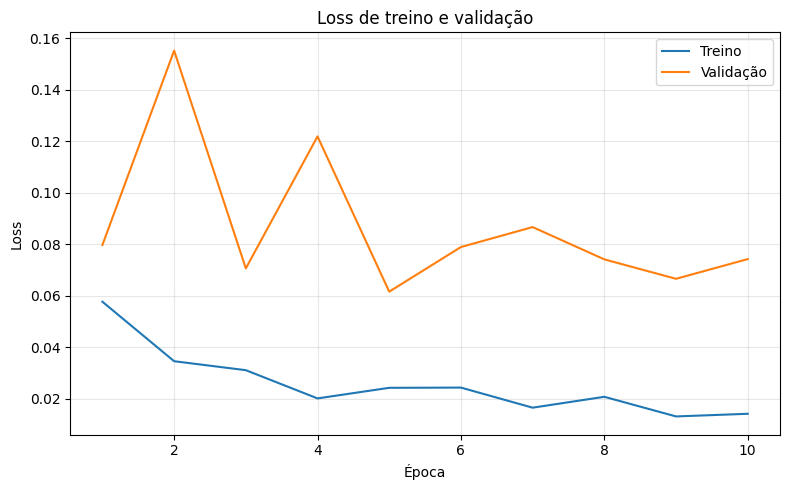

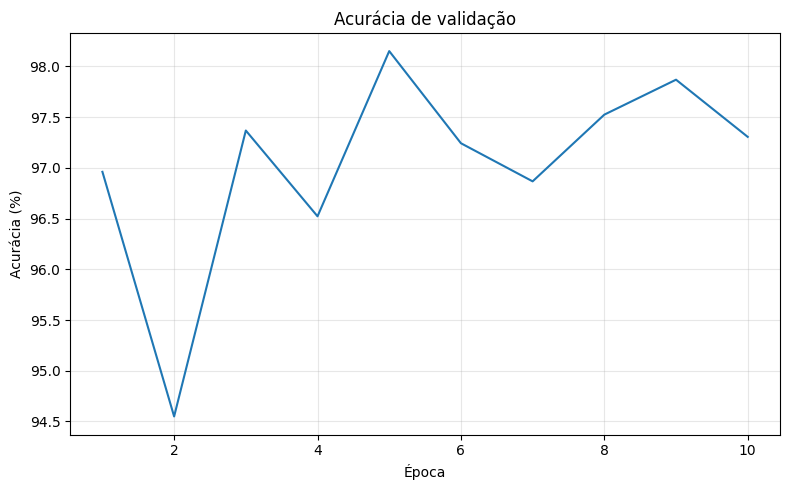

In [47]:
# ======================================================
# Curvas de treinamento
# ======================================================

epocas_executadas = range(
    1,
    len(perdas_treino) + 1,
)

plt.figure(figsize=(8, 5))

plt.plot(
    epocas_executadas,
    perdas_treino,
    label="Treino",
)

plt.plot(
    epocas_executadas,
    perdas_validacao,
    label="Validação",
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss de treino e validação")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    epocas_executadas,
    acuracias_validacao,
)

plt.xlabel("Época")
plt.ylabel("Acurácia (%)")
plt.title("Acurácia de validação")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Teste:   0%|          | 0/200 [00:00<?, ?it/s]

              precision    recall  f1-score   support

        fake     0.9849    0.9806    0.9828      1600
        real     0.9806    0.9849    0.9828      1592

    accuracy                         0.9828      3192
   macro avg     0.9828    0.9828    0.9828      3192
weighted avg     0.9828    0.9828    0.9828      3192



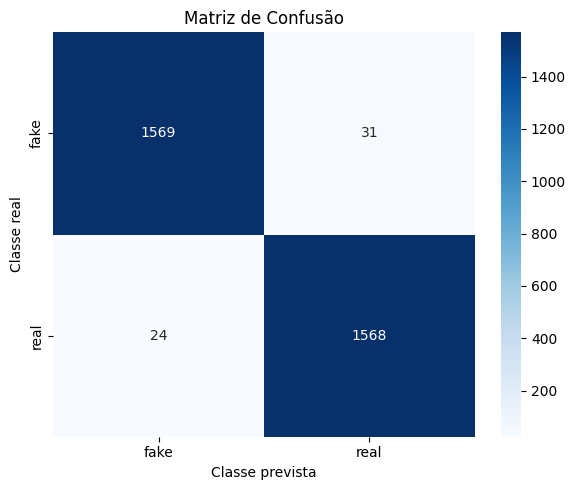

In [48]:
# ======================================================
# Avaliação no conjunto de teste
# ======================================================

rotulos_reais = []
rotulos_previstos = []

model.eval()

with torch.no_grad():

    for imagens, rotulos in tqdm(
        loader_teste,
        desc="Teste",
    ):

        imagens = imagens.to(
            device,
            non_blocking=True,
        )

        saidas = model(imagens)

        previstos = torch.argmax(
            saidas,
            dim=1,
        )

        rotulos_reais.extend(
            rotulos.tolist()
        )

        rotulos_previstos.extend(
            previstos.cpu().tolist()
        )


# ======================================================
# Relatório
# ======================================================

print(
    classification_report(
        rotulos_reais,
        rotulos_previstos,
        target_names=dataset_base.classes,
        digits=4,
    )
)


# ======================================================
# Matriz de confusão
# ======================================================

matriz_confusao = confusion_matrix(
    rotulos_reais,
    rotulos_previstos,
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_confusao,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset_base.classes,
    yticklabels=dataset_base.classes,
)

plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.title("Matriz de Confusão")

plt.tight_layout()
plt.show()


In [49]:
# ======================================================
# Salvar melhor modelo treinado
# ======================================================

PASTA_MODELOS = (
    CAMINHO_PROJETO
    / "models"
)

NOME_MODELO = "resnet34_rgb_224_1.pth"

PASTA_MODELOS.mkdir(
    parents=True,
    exist_ok=True,
)

CAMINHO_MODELO = (
    PASTA_MODELOS
    / NOME_MODELO
)

torch.save(
    model.state_dict(),
    CAMINHO_MODELO,
)

print(
    f"Modelo salvo em: "
    f"{CAMINHO_MODELO.resolve()}"
)


Modelo salvo em: /home/guilhermemathiasreis/Documents/synthetic-face-detection/models/resnet34_rgb_224_1.pth
